In [1]:
!pip install opencv-python matplotlib numpy

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 3.8 MB/s eta 0:00:11
   -- ------------------------------------- 2.1/40.2 MB 4.3 MB/s eta 0:00:09
   --- ------------------------------------ 3.1/40.2 MB 4.5 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/40.2 MB 4.5 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/40.2 MB 4.5 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/40.2 MB 4.6 MB/s eta 0:00:08
   ------- -------------------------------- 7.1/40.2 MB 4.6 MB/s eta 0:00:08
   -------- ------------------------------- 8.1/40.2 MB 4.6 MB/s eta 0:00:07
   --------- ------------------------------ 9.2/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/40.2 MB 4.7 MB/s eta 0:00:07
   ----------- ---------------------------- 11.3/40.2 MB 4.7 MB/s eta 0:00:07
   --------

###

Found images: ['Downloads/13. Laboratory and Reports/Lab 2/Media\\512x512 PNG Landscape Texture - Blue Sky.png', 'Downloads/13. Laboratory and Reports/Lab 2/Media\\kP0u2.png', 'Downloads/13. Laboratory and Reports/Lab 2/Media\\Landscape-Color.jpg', 'Downloads/13. Laboratory and Reports/Lab 2/Media\\pngtree-natural-landscape-snow-mountain-background-picture-image_2390197.jpg']


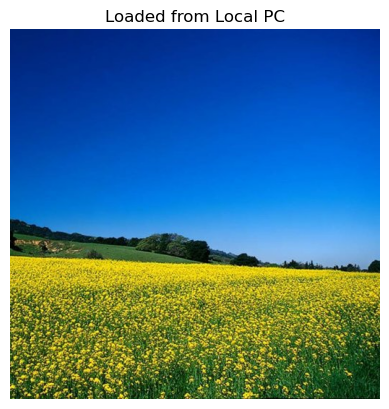

In [9]:
import cv2
import os
import matplotlib.pyplot as plt

# مسار فولدر الصور
IMAGE_DIR = "Downloads/13. Laboratory and Reports/Lab 2/Media"

# قراءة أسماء الصور
image_paths = [
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Found images:", image_paths)

# قراءة أول صورة للتجربة
img = cv2.imread(image_paths[0])

if img is None:
    print("Error loading image")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title("Loaded from Local PC")
    plt.axis("off")
    plt.show()

In [5]:
img = cv2.imread(image_paths[3])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img

array([[[ 16,  11,  20],
        [ 10,  12,  24],
        [ 10,  14,  23],
        ...,
        [237, 229, 200],
        [238, 231, 201],
        [239, 232, 202]],

       [[ 33,  22,  29],
        [ 18,  17,  29],
        [ 17,  17,  31],
        ...,
        [237, 229, 200],
        [237, 230, 200],
        [238, 230, 200]],

       [[ 46,  19,  31],
        [ 47,  21,  33],
        [ 43,  21,  34],
        ...,
        [236, 229, 201],
        [237, 230, 200],
        [238, 231, 200]],

       ...,

       [[  2,   4,  17],
        [  3,   6,  17],
        [  3,   5,  16],
        ...,
        [  6,   6,  16],
        [  4,   4,  14],
        [  4,   4,  14]],

       [[  2,   3,  16],
        [  2,   4,  17],
        [  3,   5,  17],
        ...,
        [  5,   5,  16],
        [  4,   4,  14],
        [  4,   5,  13]],

       [[  2,   3,  16],
        [  2,   4,  16],
        [  2,   4,  15],
        ...,
        [  5,   5,  15],
        [  5,   4,  14],
        [  5,   5,  14]]

### Convert to Grayscale

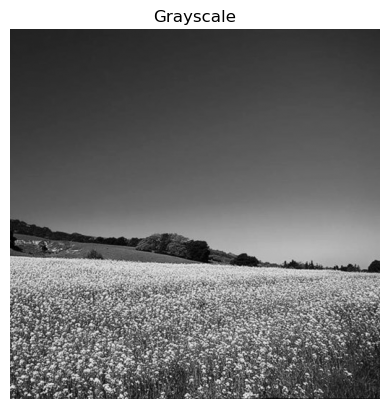

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

### Gaussian Blur
* cv2.GaussianBlur(image, (kernel_width, kernel_height), sigmaX)

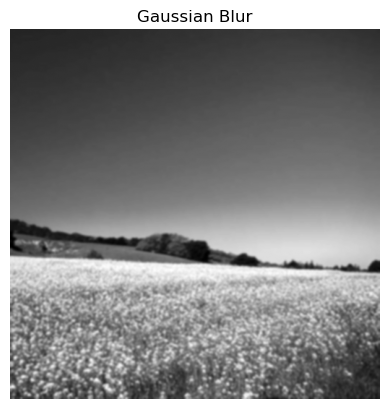

In [8]:
blur = cv2.GaussianBlur(gray, (7,7), 0)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

### Edge Detection (Canny)

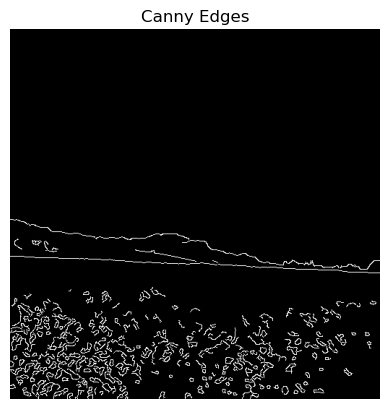

In [9]:
edges = cv2.Canny(blur, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")
plt.show()

### Thresholding

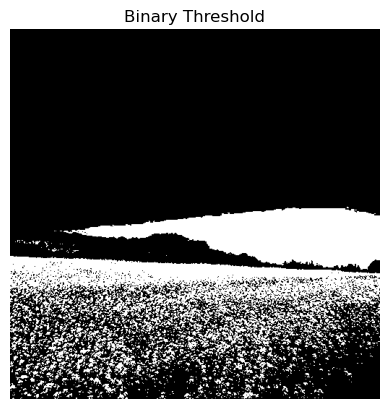

In [10]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Binary Threshold")
plt.axis("off")
plt.show()

### Histogram Equalization

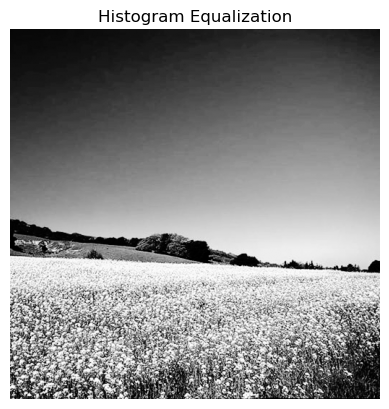

In [11]:
equalized = cv2.equalizeHist(gray)

plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalization")
plt.axis("off")
plt.show()

## Resize

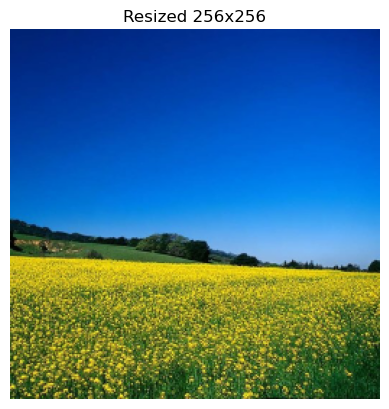

In [12]:
resized = cv2.resize(img, (256,256))

plt.imshow(resized)
plt.title("Resized 256x256")
plt.axis("off")
plt.show()

### Rotate

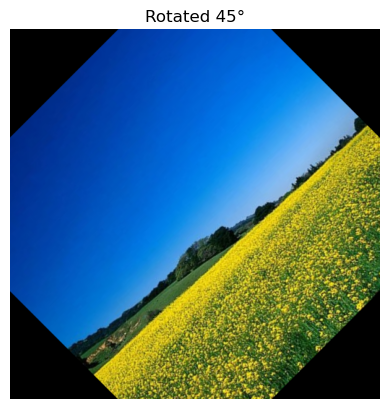

In [13]:
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

plt.imshow(rotated)
plt.title("Rotated 45°")
plt.axis("off")
plt.show()

IndexError: list index out of range

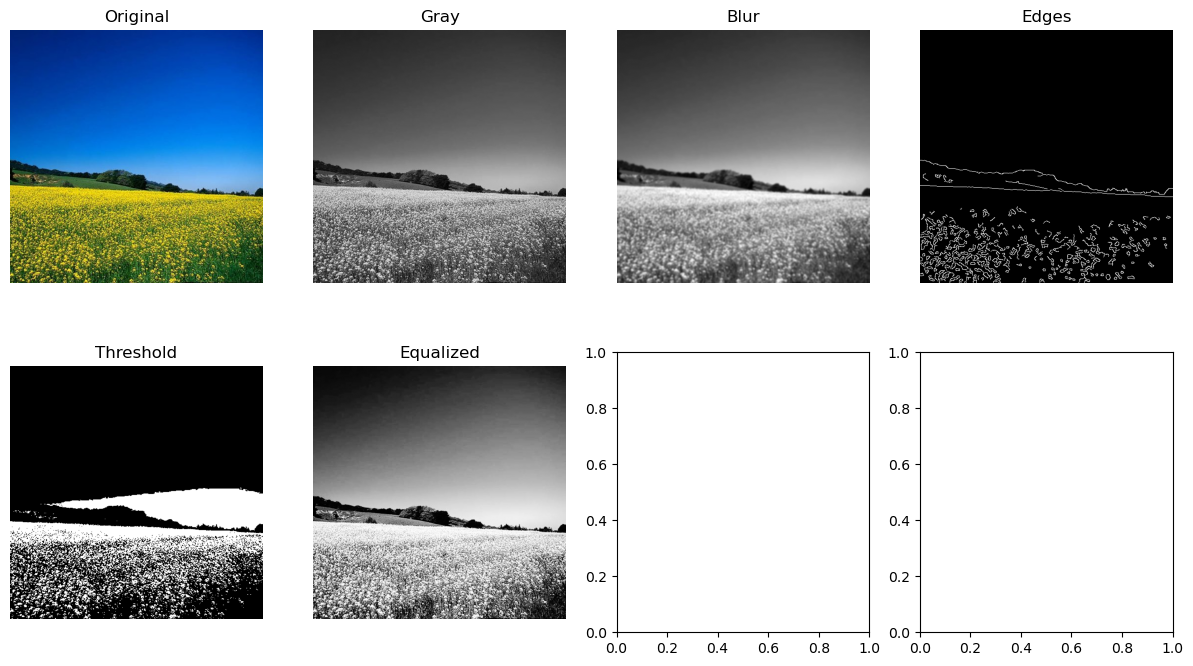

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(15,8))

images_list = [
    img,
    gray,
    blur,
    edges,
    thresh,
    equalized
]

titles = [
    "Original",
    "Gray",
    "Blur",
    "Edges",
    "Threshold",
    "Equalized"
]

for i, ax in enumerate(axes.flat):
    if len(images_list[i].shape) == 2:
        ax.imshow(images_list[i], cmap='gray')
    else:
        ax.imshow(images_list[i])
    ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Increase Image Brightness by 50

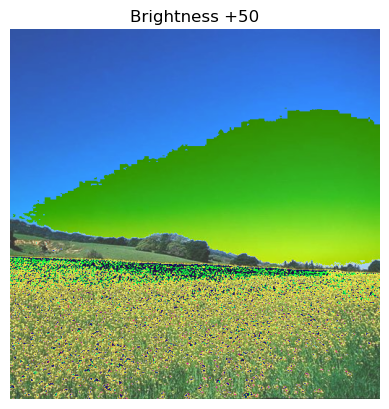

In [16]:
import numpy as np

bright = np.clip(img + 50, 0, 255).astype(np.uint8)

plt.imshow(bright)
plt.title("Brightness +50")
plt.axis("off")
plt.show()